# Tarea 3: Modelos de Clasificación (MDS, Primavera 2025)
Nombre: Patricio Espinoza A.

# Pregunta 1

In [4]:
import os
import random
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

df = pd.read_csv('heart.csv')  
target_col = 'HeartDisease'

## Parte b

In [6]:
#(b)
from sklearn.model_selection import train_test_split

# Conjuntos X e Y
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# split 80/20 con stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

In [7]:
# Variable 'HeartDesease' en y_train e y_test
print("Distribución en y_train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en y_test:")
print(y_test.value_counts(normalize=True))

# Estadísticas de 'HeartDesease' en y_train e y_test
print("\nEstadísticas en y_train:")
print(y_train.describe())

print("\nEstadísticas en y_test:")
print(y_test.describe())

Distribución en y_train:
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64

Distribución en y_test:
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64

Estadísticas en y_train:
count    734.000000
mean       0.553134
std        0.497508
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: HeartDisease, dtype: float64

Estadísticas en y_test:
count    184.000000
mean       0.554348
std        0.498394
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: HeartDisease, dtype: float64


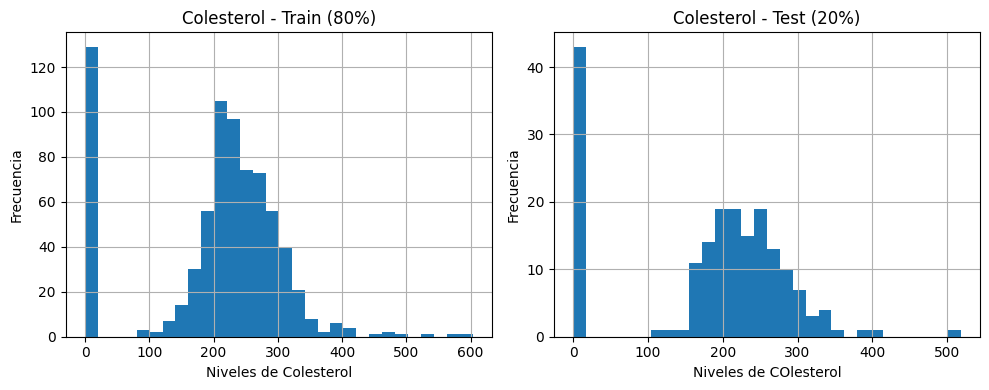


Estadísticas en X_train sin 0 en 'Cholesterol':
count    605.000000
mean     246.560331
std       59.656537
min       85.000000
25%      210.000000
50%      238.000000
75%      277.000000
max      603.000000
Name: Cholesterol, dtype: float64

Estadísticas en X_test sin 0 en 'Cholesterol':
count    141.000000
mean     236.375887
std       56.405488
min      110.000000
25%      196.000000
50%      233.000000
75%      264.000000
max      518.000000
Name: Cholesterol, dtype: float64


In [10]:
import matplotlib.pyplot as plt

if 'Cholesterol' in X.columns:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    X_train['Cholesterol'].hist(bins=30)
    plt.title("Colesterol - Train (80%)")
    plt.xlabel("Niveles de Colesterol")
    plt.ylabel("Frecuencia")
    plt.subplot(1,2,2)
    X_test['Cholesterol'].hist(bins=30)
    plt.title("Colesterol - Test (20%)")
    plt.xlabel("Niveles de COlesterol")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

# Omitir valores 0 en 'Cholesterol'
X_train_no0 = X_train[X_train['Cholesterol'] != 0]
X_test_no0 = X_test[X_test['Cholesterol'] != 0]

# Estadísticas sin 0 en 'Cholesterol'
print("\nEstadísticas en X_train sin 0 en 'Cholesterol':")
print(X_train_no0['Cholesterol'].describe())

print("\nEstadísticas en X_test sin 0 en 'Cholesterol':")
print(X_test_no0['Cholesterol'].describe())

## Parte c

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)  # = sensitivity
    f1 = f1_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    return {
        'tn':tn,'fp':fp,'fn':fn,'tp':tp,
        'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,
        'specificity':specificity,'FPR':fpr,'FNR':fnr
    }

# 0) Eliminar variables categóricas
X_train = X_train.select_dtypes(include=[np.number])
X_test  = X_test.select_dtypes(include=[np.number])

# 1) Entrenar modelo
clf = LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED)
clf.fit(X_train, y_train)

# 2) predecir en train y test
yhat_train = clf.predict(X_train)
yhat_test  = clf.predict(X_test)

# 3) métricas
metrics_train = compute_metrics(y_train, yhat_train)
metrics_test  = compute_metrics(y_test, yhat_test)

import pprint
print("Métricas - TRAIN (80%):")
pprint.pprint(metrics_train)
print("\nMétricas - TEST (20%):")
pprint.pprint(metrics_test)

Métricas - TRAIN (80%):
{'FNR': np.float64(0.21674876847290642),
 'FPR': np.float64(0.2774390243902439),
 'accuracy': 0.7561307901907357,
 'f1': 0.7803680981595092,
 'fn': np.int64(88),
 'fp': np.int64(91),
 'precision': 0.7775061124694377,
 'recall': 0.7832512315270936,
 'specificity': np.float64(0.7225609756097561),
 'tn': np.int64(237),
 'tp': np.int64(318)}

Métricas - TEST (20%):
{'FNR': np.float64(0.19607843137254902),
 'FPR': np.float64(0.2804878048780488),
 'accuracy': 0.7663043478260869,
 'f1': 0.7922705314009661,
 'fn': np.int64(20),
 'fp': np.int64(23),
 'precision': 0.780952380952381,
 'recall': 0.803921568627451,
 'specificity': np.float64(0.7195121951219512),
 'tn': np.int64(59),
 'tp': np.int64(82)}


## Parte d

In [15]:
# split 60/40
X_train_60, X_test_60, y_train_60, y_test_60 = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED
)

# Solo variables numéricas
X_train_60 = X_train_60.select_dtypes(include=[np.number])
X_test_60  = X_test_60.select_dtypes(include=[np.number])

# entrenar
clf60 = LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED)
clf60.fit(X_train_60, y_train_60)

yhat_train60 = clf60.predict(X_train_60)
yhat_test60  = clf60.predict(X_test_60)

metrics_train60 = compute_metrics(y_train_60, yhat_train60)
metrics_test60  = compute_metrics(y_test_60, yhat_test60)

print("Métricas - TRAIN (60%):"); pprint.pprint(metrics_train60)
print("\nMétricas - TEST  (40%):"); pprint.pprint(metrics_test60)

Métricas - TRAIN (60%):
{'FNR': np.float64(0.22697368421052633),
 'FPR': np.float64(0.26422764227642276),
 'accuracy': 0.7563636363636363,
 'f1': 0.7781456953642384,
 'fn': np.int64(69),
 'fp': np.int64(65),
 'precision': 0.7833333333333333,
 'recall': 0.7730263157894737,
 'specificity': np.float64(0.7357723577235772),
 'tn': np.int64(181),
 'tp': np.int64(235)}

Métricas - TEST  (40%):
{'FNR': np.float64(0.24019607843137256),
 'FPR': np.float64(0.22560975609756098),
 'accuracy': 0.7663043478260869,
 'f1': 0.7828282828282829,
 'fn': np.int64(49),
 'fp': np.int64(37),
 'precision': 0.8072916666666666,
 'recall': 0.7598039215686274,
 'specificity': np.float64(0.774390243902439),
 'tn': np.int64(127),
 'tp': np.int64(155)}


## Parte e

AUC test 80/20: 0.8705164992826399
AUC test 60/40: 0.843226924916308


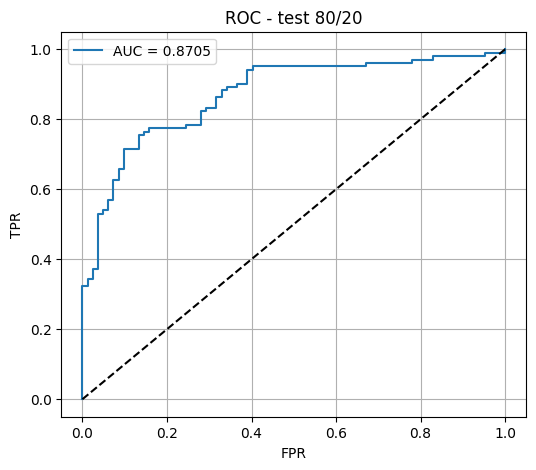

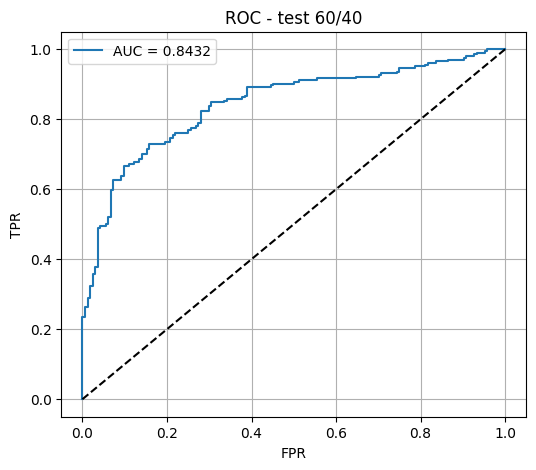

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc(y_true, y_score, title='ROC'):
    fpr, tpr, thr = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(title)
    plt.legend(); plt.grid(True)

# 80/20 (usa probabilidades del modelo clf)
y_score_test_80 = clf.predict_proba(X_test)[:,1]
plt.figure(figsize=(6,5)); plot_roc(y_test, y_score_test_80, title='ROC - test 80/20')

# 60/40
y_score_test_60 = clf60.predict_proba(X_test_60)[:,1]
plt.figure(figsize=(6,5)); plot_roc(y_test_60, y_score_test_60, title='ROC - test 60/40')

# AUC numérico
auc_80 = roc_auc_score(y_test, y_score_test_80)
auc_60 = roc_auc_score(y_test_60, y_score_test_60)
print("AUC test 80/20:", auc_80)
print("AUC test 60/40:", auc_60)


## Parte f

In [18]:
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedKFold, LeaveOneOut, LeavePOut, cross_validate

X_num = X.select_dtypes(include=['number'])

cv_objects = {
    'KFold': KFold(n_splits=5, shuffle=True, random_state=SEED),
    'StratifiedKFold': StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    'RepeatedKFold': RepeatedKFold(n_splits=5, n_repeats=2, random_state=SEED),
    'LeaveOneOut': LeaveOneOut()
}

# Ejecutar cross_validate en el dataset entero para los cv anteriores
scoring = ['accuracy', 'roc_auc', 'f1']
results = {}
for name, cv in cv_objects.items():
    print("Ejecutando CV:", name)
    res = cross_validate(LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED),
                         X_num, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    # res tiene arrays; guardamos medias y std
    results[name] = {metric: (res[f'test_{metric}'].mean(), res[f'test_{metric}'].std()) for metric in ['accuracy','roc_auc','f1']}
    print(name, results[name])

# LeavePOut sobre sub-muestra 10% y p=2 (por el costo, usar submuestra)
n_sub = max(3, int(0.1 * len(X_num))) 
sub_df = X_num.sample(n=n_sub, random_state=SEED)
sub_y  = pd.Series(y).loc[sub_df.index]
print("Submuestra para LeavePOut (10%):", sub_df.shape)
lp = LeavePOut(p=2)
res_lpo = cross_validate(LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED),
                         sub_df, sub_y, cv=lp, scoring=scoring, n_jobs=-1, return_train_score=False)
results['LeavePOut_subsample'] = {metric: (res_lpo[f'test_{metric}'].mean(), res_lpo[f'test_{metric}'].std()) for metric in ['accuracy','roc_auc','f1']}
print("LeavePOut (subsample) result:", results['LeavePOut_subsample'])

Ejecutando CV: KFold
KFold {'accuracy': (np.float64(0.7602993585174626), np.float64(0.050050459473203086)), 'roc_auc': (np.float64(0.8420343584667064), np.float64(0.04353256592818513)), 'f1': (np.float64(0.7801388096997852), np.float64(0.05481261663244077))}
Ejecutando CV: StratifiedKFold
StratifiedKFold {'accuracy': (np.float64(0.7614041339985744), np.float64(0.0301295893765597)), 'roc_auc': (np.float64(0.842107144717341), np.float64(0.03156780686695922)), 'f1': (np.float64(0.7854446762821731), np.float64(0.023674367070322812))}
Ejecutando CV: RepeatedKFold
RepeatedKFold {'accuracy': (np.float64(0.7597647897362794), np.float64(0.04101383556047346)), 'roc_auc': (np.float64(0.8407220577003873), np.float64(0.03543444736148206)), 'f1': (np.float64(0.7812606408667886), np.float64(0.04401834521493835))}
Ejecutando CV: LeaveOneOut
LeaveOneOut {'accuracy': (np.float64(0.7570806100217865), np.float64(0.42884677910744085)), 'roc_auc': (np.float64(nan), np.float64(nan)), 'f1': (np.float64(0.4335

# Pregunta 2

In [41]:
# 0. Setup
import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, roc_curve
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

csv_name = 'golf_dataset.csv'
df = pd.read_csv(csv_name)

## Parte a

In [42]:
cat_cols = ['Outlook','Windy','Holiday','Season']
num_cols = ['Temperature','Humidity','Crowdedness']
target_col = 'Play'  


# 1) crear dummies
X_cat = pd.get_dummies(df[cat_cols], drop_first=True)  
X_num = df[num_cols].astype(float).reset_index(drop=True)
X = pd.concat([X_num, X_cat.reset_index(drop=True)], axis=1)

# 2) target binario 
y = df[target_col].copy()
if y.dtype == 'O' or not set(y.unique()).issubset({0,1}):
    mapping = {v:i for i,v in enumerate(sorted(y.unique()))}  
    print("Mapping target:", mapping)
    y = y.map({mapping[k]:mapping[k] for k in mapping})  

# Final
print("X shape:", X.shape, "y distribution:\n", y.value_counts())

X shape: (7665, 11) y distribution:
 Play
0    6266
1    1399
Name: count, dtype: int64


## Parte c

In [ ]:
# Estimator base
base_clf = LogisticRegression(solver='saga', max_iter=10000, random_state=SEED)

# Definir grid evitando combos inválidos
class_weights = [None, 'balanced', {0:1, 1:5}]
param_grid = [
    {'penalty': ['l1','l2'], 'C': [0.1,1,10], 'class_weight': class_weights},
    {'penalty': ['elasticnet'], 'C': [0.1,1,10], 'class_weight': class_weights, 'l1_ratio': [0.5]}
]

scoring = {'AUC':'roc_auc', 'Accuracy':'accuracy', 'F1':'f1'}

gs = GridSearchCV(estimator=base_clf, param_grid=param_grid, cv=5,
                  scoring=scoring, refit='AUC', return_train_score=False, n_jobs=-1)

# Ejecutar (usa X, y)
gs.fit(X, y)

# Resultados
results = pd.DataFrame(gs.cv_results_)[['params','mean_test_AUC','std_test_AUC','mean_test_Accuracy','mean_test_F1']]
results = results.sort_values('mean_test_AUC', ascending=False).reset_index(drop=True)
print("Top 10 configuraciones por AUC:\n", results.head(10))
print("Mejor combinación (por AUC):", gs.best_params_, "AUC:", gs.best_score_)


Top 10 configuraciones por AUC:
                                               params  mean_test_AUC  \
0   {'C': 10, 'class_weight': None, 'penalty': 'l1'}       0.657439   
1    {'C': 1, 'class_weight': None, 'penalty': 'l1'}       0.657301   
2  {'C': 10, 'class_weight': None, 'l1_ratio': 0....       0.657297   
3   {'C': 10, 'class_weight': None, 'penalty': 'l2'}       0.657238   
4  {'C': 1, 'class_weight': None, 'l1_ratio': 0.5...       0.656380   
5    {'C': 1, 'class_weight': None, 'penalty': 'l2'}       0.655782   
6  {'C': 0.1, 'class_weight': {0: 1, 1: 5}, 'pena...       0.655414   
7  {'C': 1, 'class_weight': 'balanced', 'penalty'...       0.655158   
8  {'C': 10, 'class_weight': 'balanced', 'penalty...       0.655120   
9  {'C': 10, 'class_weight': {0: 1, 1: 5}, 'penal...       0.655112   

   std_test_AUC  mean_test_Accuracy  mean_test_F1  
0      0.010353            0.817743      0.011169  
1      0.010305            0.817613      0.005575  
2      0.010397            0.

In [33]:
# Print max AUC, Accuracy, F1
print("Mejor AUC:", results['mean_test_AUC'].max())
print("Mejor Accuracy:", results['mean_test_Accuracy'].max())
print("Mejor F1:", results['mean_test_F1'].max())

Mejor AUC: 0.6574394175844549
Mejor Accuracy: 0.8177429876060012
Mejor F1: 0.36623566970709776


## Parte d

In [43]:
# 1) split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

penalties = ['l1','l2','elasticnet']
Cs = [0.1,1,10]
class_weights = [None, 'balanced', {0:1,1:5}]

models_info = []  # dicts con params, metrics, coef, norm, etc.

for pen in penalties:
    for C in Cs:
        for cw in class_weights:
            # para elasticnet fijamos l1_ratio=0.5
            if pen == 'elasticnet':
                clf = LogisticRegression(penalty=pen, C=C, class_weight=cw,
                                         solver='saga', l1_ratio=0.5, max_iter=10000, random_state=SEED)
            else:
                clf = LogisticRegression(penalty=pen, C=C, class_weight=cw,
                                         solver='saga', max_iter=10000, random_state=SEED)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            y_score = clf.predict_proba(X_test)[:,1]
            auc = roc_auc_score(y_test, y_score)
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            coef = clf.coef_.ravel().copy()
            norm = np.linalg.norm(coef, ord=2)
            models_info.append({
                'penalty': pen, 'C': C, 'class_weight': cw,
                'auc': auc, 'accuracy': acc, 'f1': f1,
                'coef': coef, 'norm': norm
            })

# DataFrame resumen
summary_df = pd.DataFrame([{
    'penalty':m['penalty'], 'C':m['C'], 'class_weight':str(m['class_weight']),
    'auc':m['auc'],'accuracy':m['accuracy'],'f1':m['f1'],'norm':m['norm']
} for m in models_info])
print(summary_df.sort_values('auc', ascending=False).head(27))

       penalty     C  class_weight       auc  accuracy        f1      norm
0           l1   0.1          None  0.689800  0.817352  0.000000  1.696548
1           l1   0.1      balanced  0.688292  0.609915  0.382231  1.959230
2           l1   0.1  {0: 1, 1: 5}  0.686462  0.551859  0.378281  2.245777
3           l1   1.0          None  0.685673  0.817352  0.000000  2.519967
6           l1  10.0          None  0.685211  0.817352  0.000000  2.607664
15          l2  10.0          None  0.685183  0.817352  0.000000  2.594228
24  elasticnet  10.0          None  0.685166  0.817352  0.000000  2.600915
21  elasticnet   1.0          None  0.684929  0.817352  0.000000  2.458907
12          l2   1.0          None  0.684798  0.817352  0.000000  2.405084
19  elasticnet   0.1      balanced  0.684792  0.621657  0.389474  1.809836
18  elasticnet   0.1          None  0.684590  0.817352  0.000000  1.544665
20  elasticnet   0.1  {0: 1, 1: 5}  0.684493  0.543379  0.381625  2.100951
4           l1   1.0     

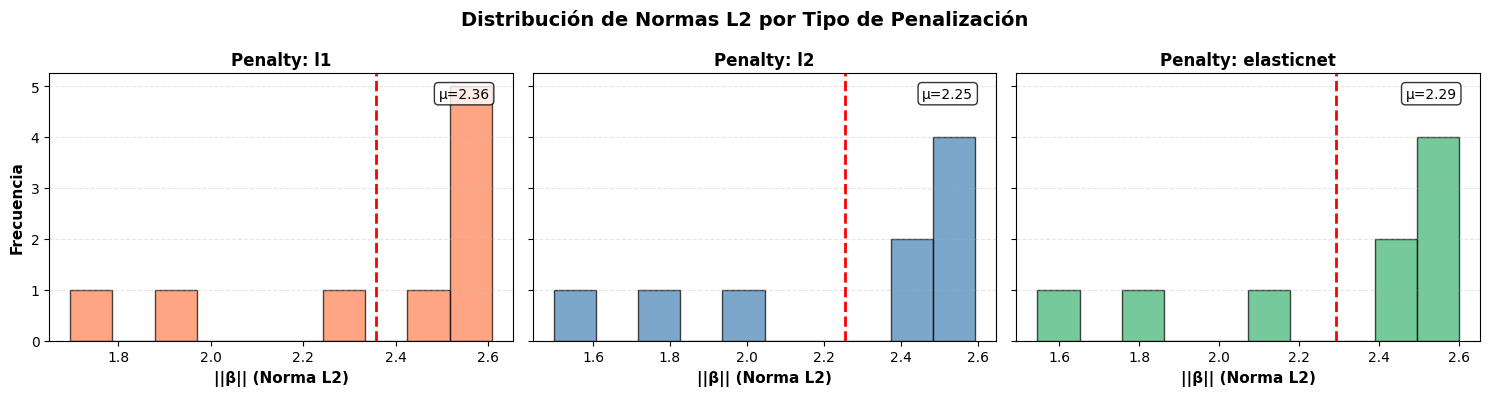

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, pen in enumerate(penalties):
    pen_norms = [m['norm'] for m in models_info if m['penalty'] == pen]
    axes[idx].hist(pen_norms, bins=10, edgecolor='black', alpha=0.7, color=['coral','steelblue','mediumseagreen'][idx])
    axes[idx].axvline(np.mean(pen_norms), color='red', linestyle='--', linewidth=2)
    axes[idx].set_xlabel('||β|| (Norma L2)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Penalty: {pen}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].text(0.95, 0.95, f'μ={np.mean(pen_norms):.2f}', 
                   transform=axes[idx].transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
fig.suptitle('Distribución de Normas L2 por Tipo de Penalización', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

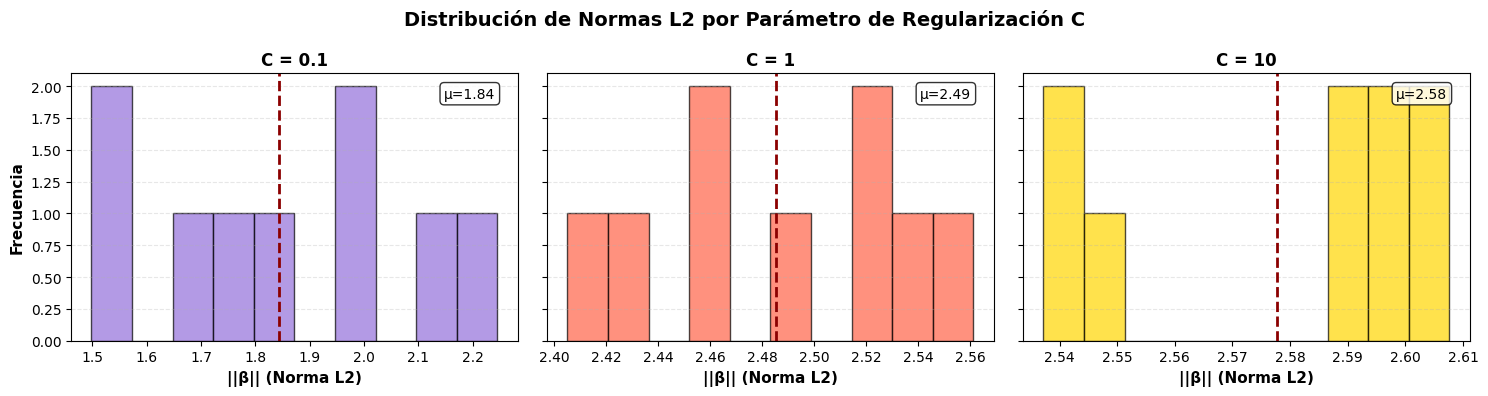

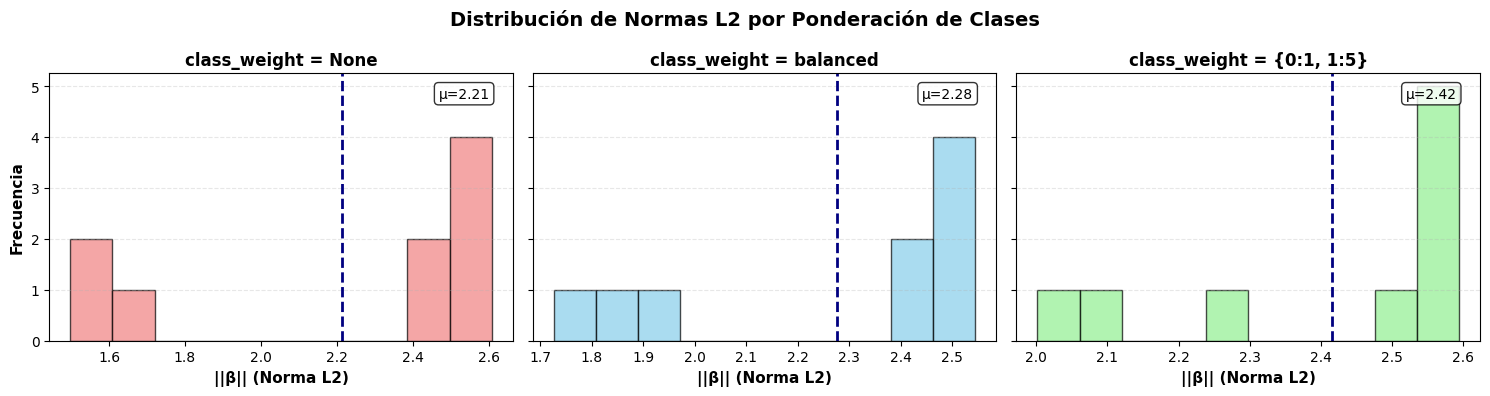

In [38]:
# Histograma separado por valor de C
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, c_val in enumerate(Cs):
    c_norms = [m['norm'] for m in models_info if m['C'] == c_val]
    axes[idx].hist(c_norms, bins=10, edgecolor='black', alpha=0.7, color=['mediumpurple','tomato','gold'][idx])
    axes[idx].axvline(np.mean(c_norms), color='darkred', linestyle='--', linewidth=2)
    axes[idx].set_xlabel('||β|| (Norma L2)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'C = {c_val}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].text(0.95, 0.95, f'μ={np.mean(c_norms):.2f}', 
                   transform=axes[idx].transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
fig.suptitle('Distribución de Normas L2 por Parámetro de Regularización C', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Histograma separado por class_weight
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

class_weight_labels = ['None', 'balanced', '{0:1, 1:5}']
class_weight_values = [None, 'balanced', {0:1, 1:5}]

for idx, (cw_val, cw_label) in enumerate(zip(class_weight_values, class_weight_labels)):
    cw_norms = [m['norm'] for m in models_info if str(m['class_weight']) == str(cw_val)]
    axes[idx].hist(cw_norms, bins=10, edgecolor='black', alpha=0.7, color=['lightcoral','skyblue','lightgreen'][idx])
    axes[idx].axvline(np.mean(cw_norms), color='navy', linestyle='--', linewidth=2)
    axes[idx].set_xlabel('||β|| (Norma L2)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'class_weight = {cw_label}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].text(0.95, 0.95, f'μ={np.mean(cw_norms):.2f}', 
                   transform=axes[idx].transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
fig.suptitle('Distribución de Normas L2 por Ponderación de Clases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Parte e

Top variables por modelo (ordenadas por |β̃|):
        penalty     C  class_weight top_variable  top_abs_value
3           l1   1.0          None  Crowdedness       0.942488
6           l1  10.0          None  Crowdedness       0.941752
24  elasticnet  10.0          None  Crowdedness       0.941301
15          l2  10.0          None  Crowdedness       0.940847
2           l1   0.1  {0: 1, 1: 5}  Crowdedness       0.940831
0           l1   0.1          None  Crowdedness       0.939946
1           l1   0.1      balanced  Crowdedness       0.938502
5           l1   1.0  {0: 1, 1: 5}  Crowdedness       0.938194
21  elasticnet   1.0          None  Crowdedness       0.937863
8           l1  10.0  {0: 1, 1: 5}  Crowdedness       0.937857
26  elasticnet  10.0  {0: 1, 1: 5}  Crowdedness       0.937690
17          l2  10.0  {0: 1, 1: 5}  Crowdedness       0.937523
4           l1   1.0      balanced  Crowdedness       0.936625
23  elasticnet   1.0  {0: 1, 1: 5}  Crowdedness       0.936562
7      

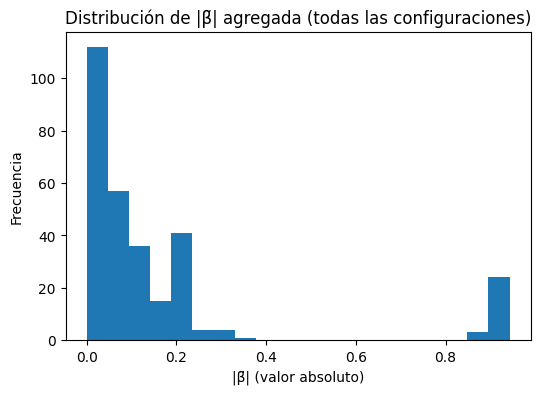

In [44]:
# calcular beta_tilde y variable de mayor contribución por modelo
feature_names = X.columns.tolist()
beta_tildes = []
top_vars = []

for m in models_info:
    coef = m['coef']
    norm = np.linalg.norm(coef)
    if norm == 0:
        beta_tilde = coef  # todos ceros
    else:
        beta_tilde = coef / norm
    beta_tildes.append(beta_tilde)
    idx_max = np.argmax(np.abs(beta_tilde))
    top_vars.append({'penalty':m['penalty'],'C':m['C'],'class_weight':str(m['class_weight']),
                     'top_variable': feature_names[idx_max], 'top_abs_value': abs(beta_tilde[idx_max])})

top_df = pd.DataFrame(top_vars).sort_values('top_abs_value', ascending=False)
print("Top variables por modelo (ordenadas por |β̃|):\n", top_df.head(27))

# Histogram agregando todos los componentes de beta_tilde
all_beta_tilde_values = np.concatenate(beta_tildes)
plt.figure(figsize=(6,4))
plt.hist(np.abs(all_beta_tilde_values), bins=20)
plt.xlabel('|β̃| (valor absoluto)')
plt.ylabel('Frecuencia')
plt.title('Distribución de |β̃| agregada (todas las configuraciones)')
plt.show()

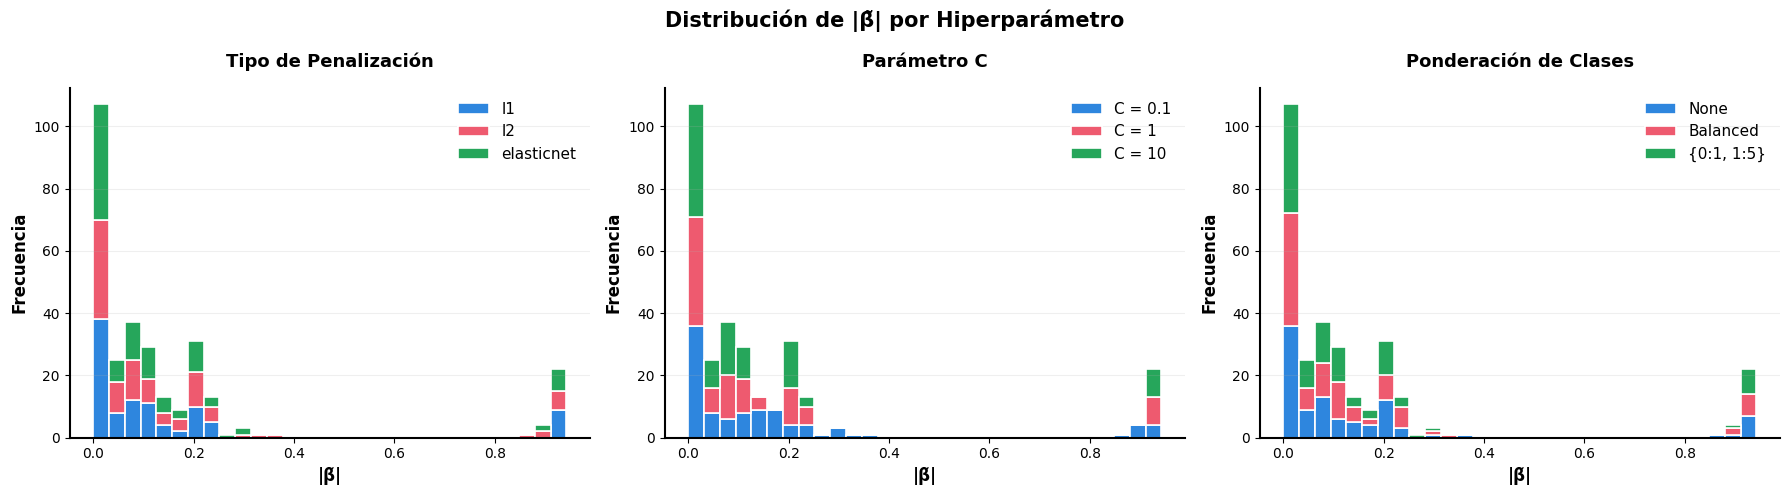

In [54]:
# Subplot 1: Por Penalty
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax in axes:
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

# === 1) Penalización ===
penalties = ['l1', 'l2', 'elasticnet']
colors_pen = ['#2E86DE', '#EE5A6F', '#26A65B']

pen_values_list = []
for pen in penalties:
    vals = []
    for m, bt in zip(models_info, beta_tildes):
        if m['penalty'] == pen:
            vals.extend(np.abs(bt))
    pen_values_list.append(vals)

axes[0].hist(pen_values_list, bins=30, stacked=True, 
             color=colors_pen, label=penalties, edgecolor='white', linewidth=1.2)

axes[0].set_xlabel('|β̃|', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Tipo de Penalización', fontsize=13, fontweight='bold', pad=15)
axes[0].legend(fontsize=11, frameon=False)
axes[0].grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.8)

# === 2) Parámetro C ===
Cs = [0.1, 1, 10]
colors_c = ['#2E86DE', '#EE5A6F', '#26A65B']

c_values_list = []
for c_val in Cs:
    vals = []
    for m, bt in zip(models_info, beta_tildes):
        if m['C'] == c_val:
            vals.extend(np.abs(bt))
    c_values_list.append(vals)

axes[1].hist(c_values_list, bins=30, stacked=True,
             color=colors_c, label=[f'C = {c}' for c in Cs],
             edgecolor='white', linewidth=1.2)

axes[1].set_xlabel('|β̃|', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[1].set_title('Parámetro C', fontsize=13, fontweight='bold', pad=15)
axes[1].legend(fontsize=11, frameon=False)
axes[1].grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.8)

# === 3) class_weight ===
class_weight_labels = ['None', 'Balanced', '{0:1, 1:5}']
class_weight_values = ['None', 'balanced', '{0: 1, 1: 5}']
colors_cw = ['#2E86DE', '#EE5A6F', '#26A65B']

cw_values_list = []
for cw_val in class_weight_values:
    vals = []
    for m, bt in zip(models_info, beta_tildes):
        if str(m['class_weight']) == cw_val:
            vals.extend(np.abs(bt))
    cw_values_list.append(vals)

axes[2].hist(cw_values_list, bins=30, stacked=True,
             color=colors_cw, label=class_weight_labels,
             edgecolor='white', linewidth=1.2)

axes[2].set_xlabel('|β̃|', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[2].set_title('Ponderación de Clases', fontsize=13, fontweight='bold', pad=15)
axes[2].legend(fontsize=11, frameon=False)
axes[2].grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.8)

fig.suptitle('Distribución de |β̃| por Hiperparámetro', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## Parte f

In [24]:
best_model = max(models_info, key=lambda m: m['auc'])
print("Mejor modelo (según AUC):", best_model['penalty'], best_model['C'], best_model['class_weight'])
print("Métricas: AUC=%.4f Acc=%.4f F1=%.4f" % (best_model['auc'], best_model['accuracy'], best_model['f1']))

Mejor modelo (según AUC): l1 0.1 None
Métricas: AUC=0.6898 Acc=0.8174 F1=0.0000


In [55]:
# Combinación que obtuvo el mejor F1
best_f1_model = max(models_info, key=lambda m: m['f1'])
print("Mejor modelo (según F1):", best_f1_model['penalty'], best_f1_model['C'], best_f1_model['class_weight'])
print("Métricas: AUC=%.4f Acc=%.4f F1=%.4f" % (best_f1_model['auc'], best_f1_model['accuracy'], best_f1_model['f1']))

Mejor modelo (según F1): l2 1 balanced
Métricas: AUC=0.6832 Acc=0.6275 F1=0.3919


# Pregunta 3

In [1]:
# 0) Setup
import os, random
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, quantile_transform
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

df = pd.read_csv('heart.csv')

target_col = 'HeartDisease'

# Mostrar balance de clases
print("Distribución target:\n", df[target_col].value_counts())

Distribución target:
 HeartDisease
1    508
0    410
Name: count, dtype: int64


## Parte a

In [2]:
# 1) Excluir ChestPainType (para a-c)
if 'ChestPainType' in df.columns:
    df_base = df.drop(columns=['ChestPainType'])
else:
    df_base = df.copy()

# 2) identificar variables categóricas (object / category) y numéricas
cat_cols = df_base.select_dtypes(include=['object','category']).columns.tolist()
num_cols = df_base.select_dtypes(include=[np.number]).columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)

print("Categóricas detectadas:", cat_cols)
print("Numéricas detectadas:", num_cols)

# 3) dummies para categóricas
X = pd.get_dummies(df_base.drop(columns=[target_col]), drop_first=True)
y = df_base[target_col].copy()

# Si y no es 0/1 convertir a 0/1
if y.dtype == 'O' or not set(y.unique()).issubset({0,1}):
    # ejemplo: 'Yes'/'No'
    if set(y.unique()) == set(['Yes','No']) or set(y.unique()) == set(['No','Yes']):
        y = (y == 'Yes').astype(int)
    else:
        from sklearn.preprocessing import LabelEncoder
        y = LabelEncoder().fit_transform(y)

# 4) split 90/10 stratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=SEED)

print("Shapes: X_train", X_train.shape, "X_test", X_test.shape)
print("Distribución train:\n", y_train.value_counts(normalize=True))
print("Distribución test:\n", y_test.value_counts(normalize=True))


Categóricas detectadas: ['Sex', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numéricas detectadas: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Shapes: X_train (826, 12) X_test (92, 12)
Distribución train:
 HeartDisease
1    0.553269
0    0.446731
Name: proportion, dtype: float64
Distribución test:
 HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


## Parte b

In [3]:
from sklearn.metrics import confusion_matrix

def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    return {'tn':tn,'fp':fp,'fn':fn,'tp':tp,
            'accuracy':acc,'precision':prec,'recall':rec,'specificity':specificity,
            'f1':f1,'FPR':fpr,'FNR':fnr}


In [4]:
def fit_and_eval(clf, X_train, y_train, X_test, y_test, name='model'):
    # Entrenar
    clf.fit(X_train, y_train)
    # Predicciones
    yhat_train = clf.predict(X_train)
    yhat_test  = clf.predict(X_test)
    m_train = compute_metrics(y_train, yhat_train)
    m_test  = compute_metrics(y_test, yhat_test)

    # scores para ROC
    def get_score_array(model, X):
        if hasattr(model, "predict_proba"):
            return model.predict_proba(X)[:,1]
        elif hasattr(model, "decision_function"):
            return model.decision_function(X)
        else:
            return model.predict(X)
    score_test = get_score_array(clf, X_test)
    auc = None
    try:
        auc = roc_auc_score(y_test, score_test)
    except Exception:
        auc = np.nan

    return {'name':name, 'clf':clf, 'train_metrics':m_train, 'test_metrics':m_test, 'auc_test':auc}


In [ ]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, solver='liblinear', random_state=SEED),
    'Perceptron': Perceptron(max_iter=1000, random_state=SEED),
    'KNN': KNeighborsClassifier(n_neighbors=5),   
    'GaussianNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis()
}

results = []
for name, clf in models.items():
    res = fit_and_eval(clf, X_train, y_train, X_test, y_test, name=name)
    results.append(res)

# Resultados en DataFrame
rows = []
for r in results:
    tr = r['train_metrics']; te = r['test_metrics']
    rows.append({
        'model': r['name'],
        'train_acc': tr['accuracy'], 'test_acc': te['accuracy'],
        'train_prec': tr['precision'], 'test_prec': te['precision'],
        'train_rec': tr['recall'], 'test_rec': te['recall'],
        'train_spec': tr['specificity'], 'test_spec': te['specificity'],
        'train_f1': tr['f1'], 'test_f1': te['f1'],
        'train_FPR': tr['FPR'], 'test_FPR': te['FPR'],
        'train_FNR': tr['FNR'], 'test_FNR': te['FNR'],
        'test_auc': r['auc_test']
    })

res_df = pd.DataFrame(rows).set_index('model')
pd.options.display.float_format = '{:.4f}'.format
print(res_df)


                    train_acc  test_acc  train_prec  test_prec  train_rec  \
model                                                                       
LogisticRegression     0.8571    0.8696      0.8661     0.8980     0.8775   
Perceptron             0.6283    0.6522      0.8538     0.8800     0.3961   
KNN                    0.7845    0.6848      0.7987     0.7200     0.8162   
GaussianNB             0.8644    0.8804      0.8726     0.9167     0.8840   
LDA                    0.8535    0.8043      0.8621     0.8511     0.8753   

                    test_rec  train_spec  test_spec  train_f1  test_f1  \
model                                                                    
LogisticRegression    0.8627      0.8320     0.8780    0.8717   0.8800   
Perceptron            0.4314      0.9160     0.9268    0.5411   0.5789   
KNN                   0.7059      0.7453     0.6585    0.8074   0.7129   
GaussianNB            0.8627      0.8401     0.9024    0.8783   0.8889   
LDA             

## Parte c

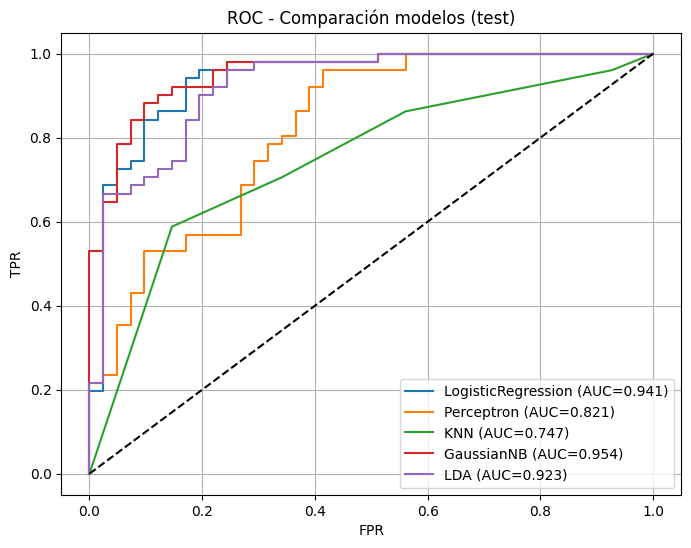

In [6]:
plt.figure(figsize=(8,6))
for r in results:
    clf = r['clf']
    name = r['name']
    # obtener score de test (prob o decision)
    try:
        if hasattr(clf, "predict_proba"):
            score = clf.predict_proba(X_test)[:,1]
        else:
            score = clf.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, score)
        auc = roc_auc_score(y_test, score)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    except Exception as e:
        print("No pude calcular ROC para", name, e)

plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC - Comparación modelos (test)')
plt.legend(); plt.grid(True); plt.show()


## Parte d

In [ ]:
# Dataset original completo (incluyendo ChestPainType)
df_all = df.copy()

# 1) Solo categóricas (incl. ChestPainType)
cat_cols_all = df_all.select_dtypes(include=['object','category']).columns.tolist()
if 'ChestPainType' not in cat_cols_all and 'ChestPainType' in df_all.columns:
    cat_cols_all.append('ChestPainType')
cat_cols_all = [c for c in cat_cols_all if c != target_col]
X_cat = pd.get_dummies(df_all[cat_cols_all], drop_first=True)
y_all = df_all[target_col].copy()
# encode y if needed
if y_all.dtype == 'O' or not set(y_all.unique()).issubset({0,1}):
    if set(y_all.unique()) == set(['Yes','No']) or set(y_all.unique()) == set(['No','Yes']):
        y_all = (y_all=='Yes').astype(int)
    else:
        from sklearn.preprocessing import LabelEncoder
        y_all = LabelEncoder().fit_transform(y_all)

# 2) Solo numéricas
num_cols_all = df_all.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols_all:
    num_cols_all.remove(target_col)
X_num = df_all[num_cols_all].copy()

# 3) Todas (numericas + dummies categoricas incl. chest)
X_all = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)

# Función que entrena y calcula AUC, Acc, F1 (usamos split 90/10 consistentemente)
def evaluate_on_dataset(Xdf, name_prefix='set'):
    Xtr, Xte, ytr, yte = train_test_split(Xdf, y_all, test_size=0.10, stratify=y_all, random_state=SEED)
    rows = []
    for model_name, clf in models.items():
        res = fit_and_eval(clf, Xtr, ytr, Xte, yte, name=model_name)
        rows.append({
            'feature_set': name_prefix,
            'model': model_name,
            'AUC': res['auc_test'],
            'Accuracy': res['test_metrics']['accuracy'],
            'F1': res['test_metrics']['f1']
        })
    return pd.DataFrame(rows)

df_cat_res = evaluate_on_dataset(X_cat, 'categóricas')
df_num_res = evaluate_on_dataset(X_num, 'numéricas')
df_all_res = evaluate_on_dataset(X_all, 'todas')

summary_compare = pd.concat([df_cat_res, df_num_res, df_all_res]).reset_index(drop=True)
print(summary_compare.pivot_table(index='model', columns='feature_set', values=['AUC','Accuracy','F1']))


                           AUC                     Accuracy                   \
feature_set        categóricas numéricas  todas categóricas numéricas  todas   
model                                                                          
GaussianNB              0.9216    0.9388 0.9665      0.8152    0.8587 0.9130   
KNN                     0.8967    0.7468 0.7468      0.8587    0.6848 0.6848   
LDA                     0.9144    0.9374 0.9570      0.8043    0.8370 0.9239   
LogisticRegression      0.9216    0.9369 0.9584      0.8152    0.8370 0.9239   
Perceptron              0.8840    0.8216 0.8111      0.7283    0.6739 0.4891   

                            F1                   
feature_set        categóricas numéricas  todas  
model                                            
GaussianNB              0.8090    0.8738 0.9184  
KNN                     0.8602    0.7129 0.7129  
LDA                     0.8163    0.8571 0.9307  
LogisticRegression      0.8172    0.8598 0.9307  
Perceptro

## Parte e

In [ ]:
from copy import deepcopy
from sklearn.preprocessing import StandardScaler, RobustScaler, quantile_transform
from sklearn.model_selection import train_test_split
import pandas as pd

# --- Definición de columnas numéricas y categóricas ---
numeric_cols = [c for c in X_all.columns if c in num_cols_all]
dummy_cols = [c for c in X_all.columns if c not in numeric_cols]

# --- Escaladores disponibles ---
scalers = {
    'standard': StandardScaler(),
    'robust': RobustScaler(),
    'quantile_normal': 'quantile_normal'  
}

# --- Función para escalar, entrenar y evaluar ---
def scale_and_eval(Xdf, scaler_key):
    # Split 90/10 para train/test 
    Xtr, Xte, ytr, yte = train_test_split(Xdf, y_all, test_size=0.10, stratify=y_all, random_state=SEED)

    # Detectar columnas numéricas a escalar
    num_to_scale = [c for c in numeric_cols if c in Xdf.columns]
    other_cols = [c for c in Xdf.columns if c not in num_to_scale]

    # Subconjuntos numéricos
    Xtr_num = Xtr[num_to_scale].copy()
    Xte_num = Xte[num_to_scale].copy()

    # Aplicar escalado según el tipo
    if scaler_key == 'quantile_normal':
        Xtr_num_scaled = pd.DataFrame(
            quantile_transform(Xtr_num, output_distribution='normal', random_state=SEED),
            columns=num_to_scale, index=Xtr.index)
        Xte_num_scaled = pd.DataFrame(
            quantile_transform(Xte_num, output_distribution='normal', random_state=SEED),
            columns=num_to_scale, index=Xte.index)
    else:
        scaler = scalers[scaler_key]
        scaler.fit(Xtr_num)
        Xtr_num_scaled = pd.DataFrame(scaler.transform(Xtr_num), columns=num_to_scale, index=Xtr.index)
        Xte_num_scaled = pd.DataFrame(scaler.transform(Xte_num), columns=num_to_scale, index=Xte.index)

    # Recomponer datasets escalados
    Xtr_scaled = pd.concat([Xtr_num_scaled.reset_index(drop=True), Xtr[other_cols].reset_index(drop=True)], axis=1)
    Xte_scaled = pd.concat([Xte_num_scaled.reset_index(drop=True), Xte[other_cols].reset_index(drop=True)], axis=1)

    # Evaluar todos los modelos
    rows = []
    for model_name, clf in models.items():
        res = fit_and_eval(deepcopy(clf), Xtr_scaled, ytr, Xte_scaled, yte, name=model_name)
        rows.append({
            'Scaler': scaler_key,
            'Modelo': model_name,
            'AUC': res['auc_test'],
            'Accuracy': res['test_metrics']['accuracy'],
            'F1': res['test_metrics']['f1']
        })

    return pd.DataFrame(rows)

# --- Aplicar a cada escalador sobre el conjunto completo (X_all) ---
scaled_standard = scale_and_eval(X_all, 'standard')
scaled_robust   = scale_and_eval(X_all, 'robust')
scaled_qnorm    = scale_and_eval(X_all, 'quantile_normal')

# --- Unir resultados ---
scaled_summary = pd.concat([scaled_standard, scaled_robust, scaled_qnorm], ignore_index=True)

# --- Tabla final: muestra AUC, Accuracy y F1 por modelo y escalador ---
summary_table = scaled_summary.pivot_table(
    index='Modelo',
    columns='Scaler',
    values=['AUC', 'Accuracy', 'F1'],
    aggfunc='mean'
).round(4)

print("\n=== Resultados promedio por modelo y tipo de escalador ===")
print(summary_table)



=== Resultados promedio por modelo y tipo de escalador ===
                               AUC                        Accuracy         \
Scaler             quantile_normal robust standard quantile_normal robust   
Modelo                                                                      
GaussianNB                  0.9484 0.9665   0.9665          0.9022 0.9130   
KNN                         0.9668 0.9512   0.9627          0.9348 0.8913   
LDA                         0.9541 0.9570   0.9570          0.9022 0.9239   
LogisticRegression          0.9541 0.9579   0.9584          0.9130 0.9239   
Perceptron                  0.8345 0.8900   0.9230          0.7391 0.7935   

                                         F1                  
Scaler             standard quantile_normal robust standard  
Modelo                                                       
GaussianNB           0.9130          0.9109 0.9184   0.9184  
KNN                  0.9239          0.9412 0.9000   0.9320  
LDA          

c:\Users\pbast\Desktop\Universidad\VIV Semestre\Aprendizaje de Máquinas\venv\Lib\site-packages\sklearn\preprocessing\_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (826). n_quantiles is set to n_samples.
  warnings.warn(
c:\Users\pbast\Desktop\Universidad\VIV Semestre\Aprendizaje de Máquinas\venv\Lib\site-packages\sklearn\preprocessing\_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (92). n_quantiles is set to n_samples.
  warnings.warn(
